In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3,5,6,7"
import textattack
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import pandas as pd
from langdetect import detect

In [5]:
from tqdm import tqdm, trange

from datasets import load_dataset
import pandas as pd
import functools
import sys
from pathlib import Path
from typing import Callable

# import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import eindex
# from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    HookedEncoderDecoder,
    HookedEncoder,
    utils,
)
from transformer_lens.hook_points import HookPoint

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import AutoTokenizer
from transformer_lens import HookedTransformer
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print("Available CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Available CUDA devices: 6
Device 0: NVIDIA H100 80GB HBM3
Device 1: NVIDIA H100 80GB HBM3
Device 2: NVIDIA H100 80GB HBM3
Device 3: NVIDIA H100 80GB HBM3
Device 4: NVIDIA H100 80GB HBM3
Device 5: NVIDIA H100 80GB HBM3


## Attack

In [4]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased')
model.load_state_dict(torch.load('bert_classifier_vanilla/model_epoch_1_acc_0.9372.pt', map_location=device))
# model.load_state_dict(torch.load('finetuned_bert/jigsaw/transformer.pth', map_location=device))
model_wrapper = textattack.models.wrappers.HuggingFaceModelWrapper(model, tokenizer)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1210778/2125951756.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We

In [5]:
df = pd.read_csv('jigsaw/test.csv')

In [6]:
df.comment_text = df.comment_text.str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
df.comment_text = df.comment_text.str.strip()
drop_indices = []
for i in trange(len(df)):
    try:
        if detect(df.comment_text[i]) != 'en':
            drop_indices.append(i)
    except:
        drop_indices.append(i)
df = df.drop(drop_indices).reset_index(drop=True)

100%|██████████| 63978/63978 [05:11<00:00, 205.69it/s]


In [7]:
jigsaw_data = list(zip(df['comment_text'], df['toxic']))
dataset = textattack.datasets.dataset.Dataset(jigsaw_data)

In [26]:
attack = textattack.attack_recipes.hotflip_ebrahimi_2017.HotFlipEbrahimi2017.build(model_wrapper)

ValueError: Cannot perform GradientBasedWordSwap on model BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias

../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [32,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [33,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [34,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [35,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [36,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,0,0], thread: [37,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1308: indexSelectLargeIndex: block: [864,

In [25]:
attack_args = textattack.AttackArgs(num_examples=1000, log_to_csv="input_reduction_log.csv", disable_stdout=True, parallel=True, checkpoint_dir="checkpoints", checkpoint_interval=1000, shuffle=True, query_budget=1)
attacker = textattack.Attacker(attack, dataset, attack_args)
attacker.attack_dataset()

textattack: Logging to CSV at path input_reduction_log.csv
textattack: Running 6 worker(s) on 6 GPU(s).
2025-05-27 16:37:30.511542: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 16:37:30.529133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748363850.549458 1207923 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748363850.555459 1207923 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748363850.571574 1207923 c

KeyboardInterrupt: 

## Patching

In [22]:
jigsaw_aug = pd.read_csv('input_reduction_log.csv')

In [23]:
jigsaw_aug[jigsaw_aug.original_output != jigsaw_aug.perturbed_output]

,original_text,perturbed_text,original_score,perturbed_score,original_output,perturbed_output,ground_truth_output,num_queries,result_type


In [11]:
jigsaw_aug.drop(jigsaw_aug.columns.difference(["perturbed_text", "ground_truth_output"]), axis=1).to_csv('jigsaw_deepword.csv', index=False)

In [12]:
dataset = load_dataset("csv", data_files={'input_reduction_log2.csv'})
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.pad_token)

# Tokenization function
def tokenize_data(example):
    return tokenizer(example["original_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 10 examples [00:00, 1597.95 examples/s]


[PAD]


Map: 100%|██████████| 10/10 [00:00<00:00, 539.37 examples/s]


In [13]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels"]}

# Create PyTorch DataLoaders
batch_size = 64
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [7]:
class BERTClassifier(nn.Module):
    def __init__(self, transformer, num_classes=2):
        super().__init__()
        self.transformer = transformer
        self.classifier = nn.Linear(transformer.cfg.d_model, num_classes)  # d_model = 768

    def forward(self, input_ids):
        _, cache = self.transformer.run_with_cache(input_ids)  # Get cache

        # Extract final hidden states from residual stream
        hidden_states = cache["resid_post", -1]  # Shape: [batch, seq_len, hidden_dim]

        # Use last token’s hidden state for classification
        logits = self.classifier(hidden_states[:, -1, :])  # Shape: [batch, num_classes]
        return logits

    def run_with_hooks(self, tokens, fwd_hooks):
        with torch.no_grad():
            with self.transformer.hooks(fwd_hooks=fwd_hooks):
                _, cache = self.transformer.run_with_cache(tokens)
            hidden_states = cache["resid_post", -1] 
            logits = self.classifier(hidden_states[:, -1, :])
        return logits


# Initialize model and optimizer
num_classes = 2
model = HookedEncoder.from_pretrained("bert-base-uncased", device=device)
model.load_state_dict(torch.load("finetuned_bert/jigsaw/transformer.pth", map_location=device))
model.to(device)
classifier = BERTClassifier(model, num_classes)
classifier.load_state_dict(torch.load("finetuned_bert/jigsaw/classifier.pth", map_location=device))
classifier.to(device)

criterion = nn.CrossEntropyLoss()

If using BERT for interpretability research, keep in mind that BERT has some significant architectural differences to GPT. For example, LayerNorms are applied *after* the attention and MLP components, meaning that the last LayerNorm in a block cannot be folded.


Moving model to device:  cuda
Loaded pretrained model bert-base-uncased into HookedEncoder


/tmp/ipykernel_1211986/1181877843.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("finetuned_bert/jigsaw/transformer.pth", map_location

Moving model to device:  cuda


/tmp/ipykernel_1211986/1181877843.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load("finetuned_bert/jigsaw/classifier.pth", map_loca

In [9]:
from transformer_lens.pretrained.weight_conversions.bert import (
 convert_tl_state_dict_to_hf,
)

hf_state_dict = convert_tl_state_dict_to_hf(model.state_dict())

ImportError: cannot import name 'convert_tl_state_dict_to_hf' from 'transformer_lens.pretrained.weight_conversions.bert' (/home/kokil/shaz/interp-toxicity/interp-toxicity/lib/python3.10/site-packages/transformer_lens/pretrained/weight_conversions/bert.py)

In [8]:
model.save_pretrained("finetuned_bert/jigsaw/transformer_hf.pth")

AttributeError: 'HookedEncoder' object has no attribute 'save_pretrained'

In [15]:
def get_log_probs(
    logits: Float[Tensor, "batch posn d_vocab"], tokens: Int[Tensor, "batch posn"]
) -> Float[Tensor, "batch posn-1"]:
    logprobs = logits.log_softmax(dim=-1)
    # We want to get logprobs[b, s, tokens[b, s+1]], in eindex syntax this looks like:
    print(logits.shape, logprobs.shape, tokens.shape)
    correct_logprobs = eindex(logprobs, tokens, "b s [b s+1]")
    return correct_logprobs

def head_zero_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:
    z[:, :, head_index_to_ablate, :] = 0.0

def get_ablation_scores(
    classifier: BERTClassifier,
    tokens: Int[Tensor, "batch seq"],
    labels,
    ablation_function: Callable = head_zero_ablation_hook,
) -> Float[Tensor, "n_layers n_heads"]:
    """
    Returns a tensor of shape (n_layers, n_heads) containing the increase in cross entropy loss from ablating the output
    of each head.
    """
    # Initialize an object to store the ablation scores
    ablation_scores = t.zeros((classifier.transformer.cfg.n_layers, classifier.transformer.cfg.n_heads), device=classifier.transformer.cfg.device)
    ablated_pred_list = {}
    # Calculating loss without any ablation, to act as a baseline
    classifier.transformer.reset_hooks()
    logits = classifier(tokens)
    preds = logits.argmax(dim=-1)
    loss_no_ablation = criterion(logits, labels)

    for layer in range(classifier.transformer.cfg.n_layers):
        ablated_pred_list[layer] = {}
        for head in range(classifier.transformer.cfg.n_heads):
            # Use functools.partial to create a temporary hook function with the head number fixed
            temp_hook_fn = functools.partial(ablation_function, head_index_to_ablate=head)
            # Run the model with the ablation hook
            ablated_logits = classifier.run_with_hooks(tokens, fwd_hooks=[(utils.get_act_name("z", layer), temp_hook_fn)])
            # Calculate the loss difference (= negative correct logprobs), only on the last `seq_len` tokens
            # loss = -get_log_probs(ablated_logits.log_softmax(-1), tokens)[:, -(seq_len - 1) :].mean()
            loss = criterion(ablated_logits, labels)
            # Store the result, subtracting the clean loss so that a value of zero means no change in loss
            ablation_scores[layer, head] = loss - loss_no_ablation
            ablated_preds = ablated_logits.argmax(dim=-1)
            ablated_pred_list[layer][head] = ablated_preds

    return ablation_scores, preds, ablated_pred_list


In [16]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(classifier.transformer.cfg.n_heads)} for layer in range(classifier.transformer.cfg.n_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels = batch["input_ids"].to(device), batch["labels"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(classifier, input_ids, labels, head_zero_ablation_hook)
    base_preds += base_pred.tolist()
    for layer in range(classifier.transformer.cfg.n_layers):
        for head in range(classifier.transformer.cfg.n_heads):
            ablated_preds[layer][head] += ablated_pred_list[layer][head].tolist()
    ablation_scores += tmp_ablation_scores
    if i % 16 == 0:
        torch.save(ablation_scores / ((i+1) * batch_size), "input_reduction/bert_ablation_scores_jigsaw_perturbed2.pth")
with open('input_reduction/bert_ablated_preds_jigsaw_perturbed2.json', 'w') as f:
    json.dump(ablated_preds, f)
with open('input_reduction/bert_base_preds_jigsaw_perturbed2.json', 'w') as f:
    json.dump(base_preds, f)

ablation_scores /= len(val_dataloader)
torch.save(ablation_scores, "input_reduction/bert_ablation_scores_jigsaw_perturbed2.pth")

patching


100%|██████████| 1/1 [00:03<00:00,  3.83s/it]


## Analysis

In [17]:
attack_name = "input_reduction"

In [18]:
ablation_scores = torch.load(f"{attack_name}/bert_ablation_scores_jigsaw_perturbed2.pth", map_location=torch.device('cpu'))

/tmp/ipykernel_1186964/436560830.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ablation_scores = torch.load(f"{attack_name}/bert_ablation_scores_jigsaw_perturbed2.pth"

In [19]:
ablation_scores.shape

torch.Size([12, 12])

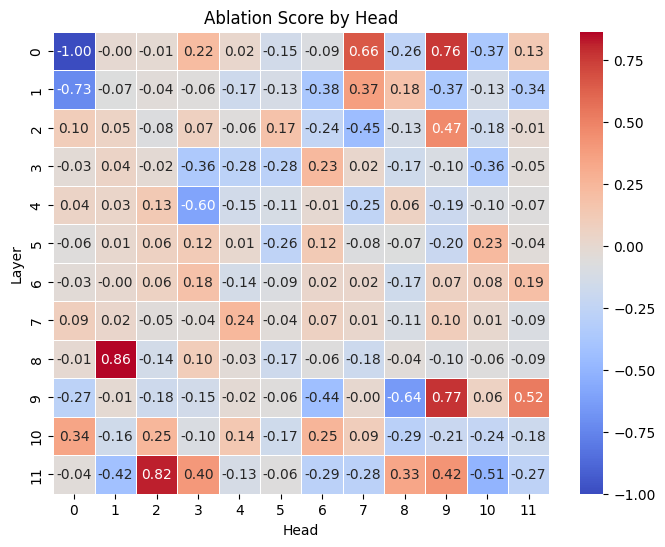

In [20]:
tensor_np = ablation_scores.cpu().detach().numpy()
tensor_min = tensor_np.min()
tensor_max = tensor_np.max()

# Shift so that 0 stays at 0
if abs(tensor_max) > abs(tensor_min):
    scale = tensor_max
else:
    scale = -tensor_min

if scale != 0:
    tensor_np = tensor_np / scale
else:
    tensor_np = np.zeros_like(tensor_np)


# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'{attack_name}/bert_jigsaw_perturbed_ablation_scores_by_head.png')
# Show the plot
plt.show()

In [21]:
base_preds = json.load(open(f'{attack_name}/bert_base_preds_jigsaw_perturbed2.json'))

In [22]:
ablated_preds = json.load(open(f'{attack_name}/bert_ablated_preds_jigsaw_perturbed2.json'))

In [24]:
df = pd.read_csv(f'{attack_name}_log2.csv')

In [25]:
base_acc = (df.ground_truth_output == base_preds).mean()

In [26]:
acc_scores = np.zeros((12,12))
for i in range(12):
    for j in range(12):
        acc_scores[i][j] = (df.ground_truth_output == ablated_preds[str(i)][str(j)]).mean()

In [27]:
acc_scores -= base_acc

In [28]:
base_acc

0.3

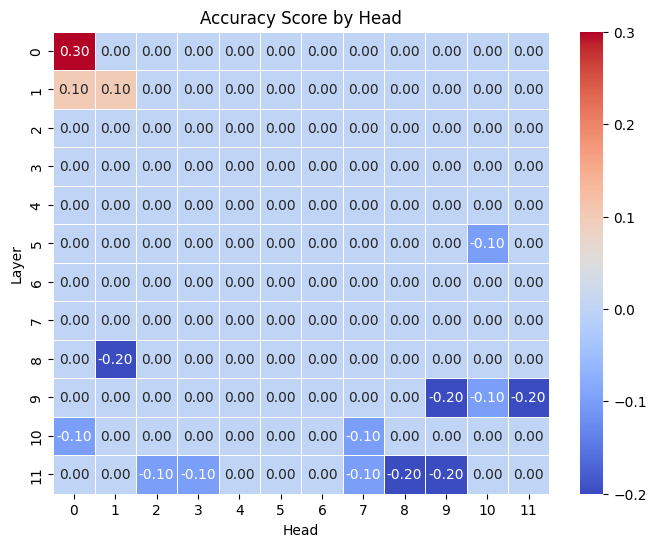

In [29]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(acc_scores, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'{attack_name}/bert_jigsaw_perturbed_accuracy_scores_by_head.png')
# Show the plot
plt.show()

## Base Scores

In [36]:
df.head()

,original_text,perturbed_text,original_score,perturbed_score,original_output,perturbed_output,ground_truth_output,num_queries,result_type
0,[[Trustworthiness]] <SPLIT><SPLIT> I [[think...,<SPLIT><SPLIT> I the point not at all kinda...,0.003999,0.603999,0,0,0,401,Maximized
1,[[Well]] [[when]] [[the]] article [[is]] [[sub...,article and then lead be longer at this small ...,0.009007,0.567565,0,0,0,174,Maximized
2,[[3RR]] <SPLIT><SPLIT> [[You]] have [[been]] ...,<SPLIT><SPLIT> have blocked 24 revert rule ed...,0.037027,0.666193,0,0,0,45,Maximized
3,[[ImageRcolournewjpg]] <SPLIT><SPLIT> [[align...,<SPLIT><SPLIT> cellpadding4 cellspacing4 back...,0.008473,0.627116,0,0,0,192,Maximized
4,[[original]] [[research]] [[Lambert]] the [[wo...,the says Graysons not valid other confirmed as...,0.008124,0.625992,0,0,0,200,Maximized


In [39]:
dataset = load_dataset("csv", data_files={f'{attack_name}_log.csv'})
print(len(dataset['train']))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.pad_token)

# Tokenization function
def tokenize_data(example):
    return tokenizer(example["original_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels"]}

# Create PyTorch DataLoaders
batch_size = 64
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)
class BERTClassifier(nn.Module):
    def __init__(self, transformer, num_classes=2):
        super().__init__()
        self.transformer = transformer
        self.classifier = nn.Linear(transformer.cfg.d_model, num_classes)  # d_model = 768

    def forward(self, input_ids):
        _, cache = self.transformer.run_with_cache(input_ids)  # Get cache

        # Extract final hidden states from residual stream
        hidden_states = cache["resid_post", -1]  # Shape: [batch, seq_len, hidden_dim]

        # Use last token's hidden state for classification
        logits = self.classifier(hidden_states[:, -1, :])  # Shape: [batch, num_classes]
        return logits

    def run_with_hooks(self, tokens, fwd_hooks):
        with torch.no_grad():
            with self.transformer.hooks(fwd_hooks=fwd_hooks):
                _, cache = self.transformer.run_with_cache(tokens)
            hidden_states = cache["resid_post", -1] 
            logits = self.classifier(hidden_states[:, -1, :])
        return logits


# Initialize model and optimizer
num_classes = 2
model = HookedEncoder.from_pretrained("bert-base-uncased", device=device)
# model.load_state_dict(torch.load("finetuned_gpt2/transformer.pth", map_location=device))
model.to(device)
classifier = BERTClassifier(model, num_classes)
# classifier.load_state_dict(torch.load("finetuned_gpt2/classifier.pth", map_location=device))
classifier.to(device)
criterion = nn.CrossEntropyLoss()
def get_log_probs(
    logits: Float[Tensor, "batch posn d_vocab"], tokens: Int[Tensor, "batch posn"]
) -> Float[Tensor, "batch posn-1"]:
    logprobs = logits.log_softmax(dim=-1)
    # We want to get logprobs[b, s, tokens[b, s+1]], in eindex syntax this looks like:
    print(logits.shape, logprobs.shape, tokens.shape)
    correct_logprobs = eindex(logprobs, tokens, "b s [b s+1]")
    return correct_logprobs

def head_zero_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:
    z[:, :, head_index_to_ablate, :] = 0.0

def get_ablation_scores(
    classifier: BERTClassifier,
    tokens: Int[Tensor, "batch seq"],
    labels,
    ablation_function: Callable = head_zero_ablation_hook,
) -> Float[Tensor, "n_layers n_heads"]:
    """
    Returns a tensor of shape (n_layers, n_heads) containing the increase in cross entropy loss from ablating the output
    of each head.
    """
    # Initialize an object to store the ablation scores
    ablation_scores = t.zeros((classifier.transformer.cfg.n_layers, classifier.transformer.cfg.n_heads), device=classifier.transformer.cfg.device)
    ablated_pred_list = {}
    # Calculating loss without any ablation, to act as a baseline
    classifier.transformer.reset_hooks()
    logits = classifier(tokens)
    preds = logits.argmax(dim=-1)
    loss_no_ablation = criterion(logits, labels)

    for layer in range(classifier.transformer.cfg.n_layers):
        ablated_pred_list[layer] = {}
        for head in range(classifier.transformer.cfg.n_heads):
            # Use functools.partial to create a temporary hook function with the head number fixed
            temp_hook_fn = functools.partial(ablation_function, head_index_to_ablate=head)
            # Run the model with the ablation hook
            ablated_logits = classifier.run_with_hooks(tokens, fwd_hooks=[(utils.get_act_name("z", layer), temp_hook_fn)])
            # Calculate the loss difference (= negative correct logprobs), only on the last `seq_len` tokens
            # loss = -get_log_probs(ablated_logits.log_softmax(-1), tokens)[:, -(seq_len - 1) :].mean()
            loss = criterion(ablated_logits, labels)
            # Store the result, subtracting the clean loss so that a value of zero means no change in loss
            ablation_scores[layer, head] = loss - loss_no_ablation
            ablated_preds = ablated_logits.argmax(dim=-1)
            ablated_pred_list[layer][head] = ablated_preds

    return ablation_scores, preds, ablated_pred_list

50000


Support for BERT in TransformerLens is currently experimental, until such a time when it has feature parity with HookedTransformer and has been tested on real research tasks. Until then, backward compatibility is not guaranteed. Please see the docs for information on the limitations of the current implementation.
If using BERT for interpretability research, keep in mind that BERT has some significant architectural differences to GPT. For example, LayerNorms are applied *after* the attention and MLP components, meaning that the last LayerNorm in a block cannot be folded.


[PAD]
Moving model to device:  cuda
Loaded pretrained model bert-base-uncased into HookedEncoder
Moving model to device:  cuda


In [ ]:
all_preds = []
all_labels = []
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels = batch["input_ids"].to(device), batch["labels"].to(device)
    logits = classifier(input_ids)
    preds = logits.argmax(dim=-1)
    


'[[Trustworthiness]]   <SPLIT><SPLIT> I [[think]] [[the]] [[section]] [[on]] [[trustworthiness]] [[misses]] the [[point]]  [[The]] point [[it]] [[seems]] [[to]] [[make]] [[is]] [[this]] [[should]] not [[work]] at all [[but]] [[it]] kinda looks like [[it]] [[seems]] [[like]] it might [[at]] least so [[far]] so meh  [[Not]] exactly [[a]] [[ringing]] [[endorsement]] <SPLIT><SPLIT> [[I]] [[would]] [[argue]] [[it]] [[will]] [[work]] and it [[will]] be [[trustworthy]] [[and]] that [[this]] [[type]] [[of]] system has [[been]] [[under]] [[test]] [[for]] [[about]] [[4]] [[billion]] years  [[Life]] [[evolved]] to [[the]] working examples that it [[is]] [[through]] random mutation and natural [[selection]]  [[Wikis]] [[evolve]] [[through]] usually nonrandom [[and]] intelligent mutation and [[usually]] [[intelligent]] selection [[based]] on [[facts]]  [[So]] [[it]] should [[not]] [[only]] work [[as]] well as [[evolution]] it should work [[far]] better and [[far]] [[faster]]  Just like there [[are]